Plotting histogram for tp_down...


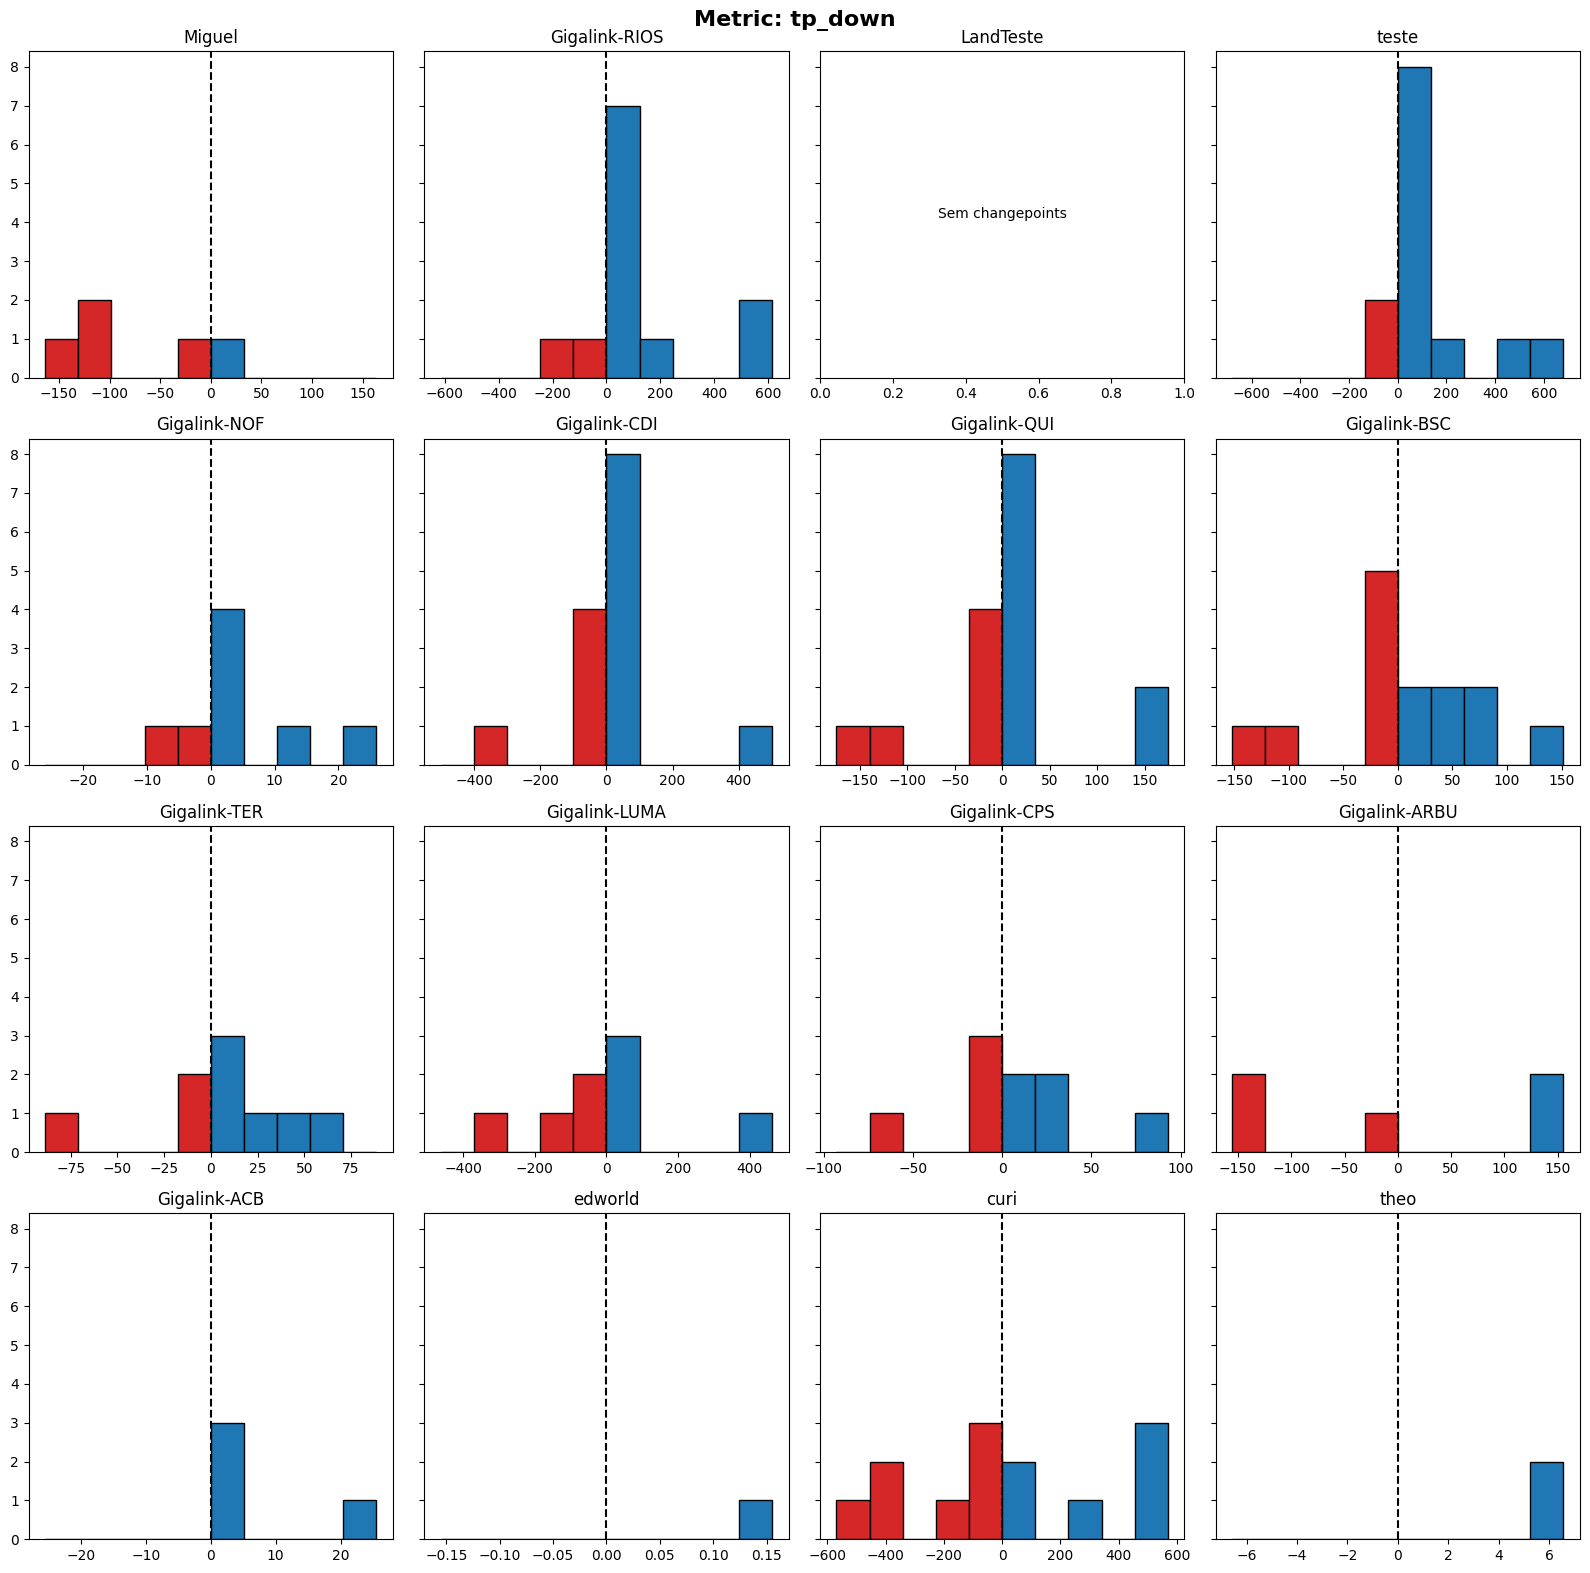

Plotting histogram for tp_up...


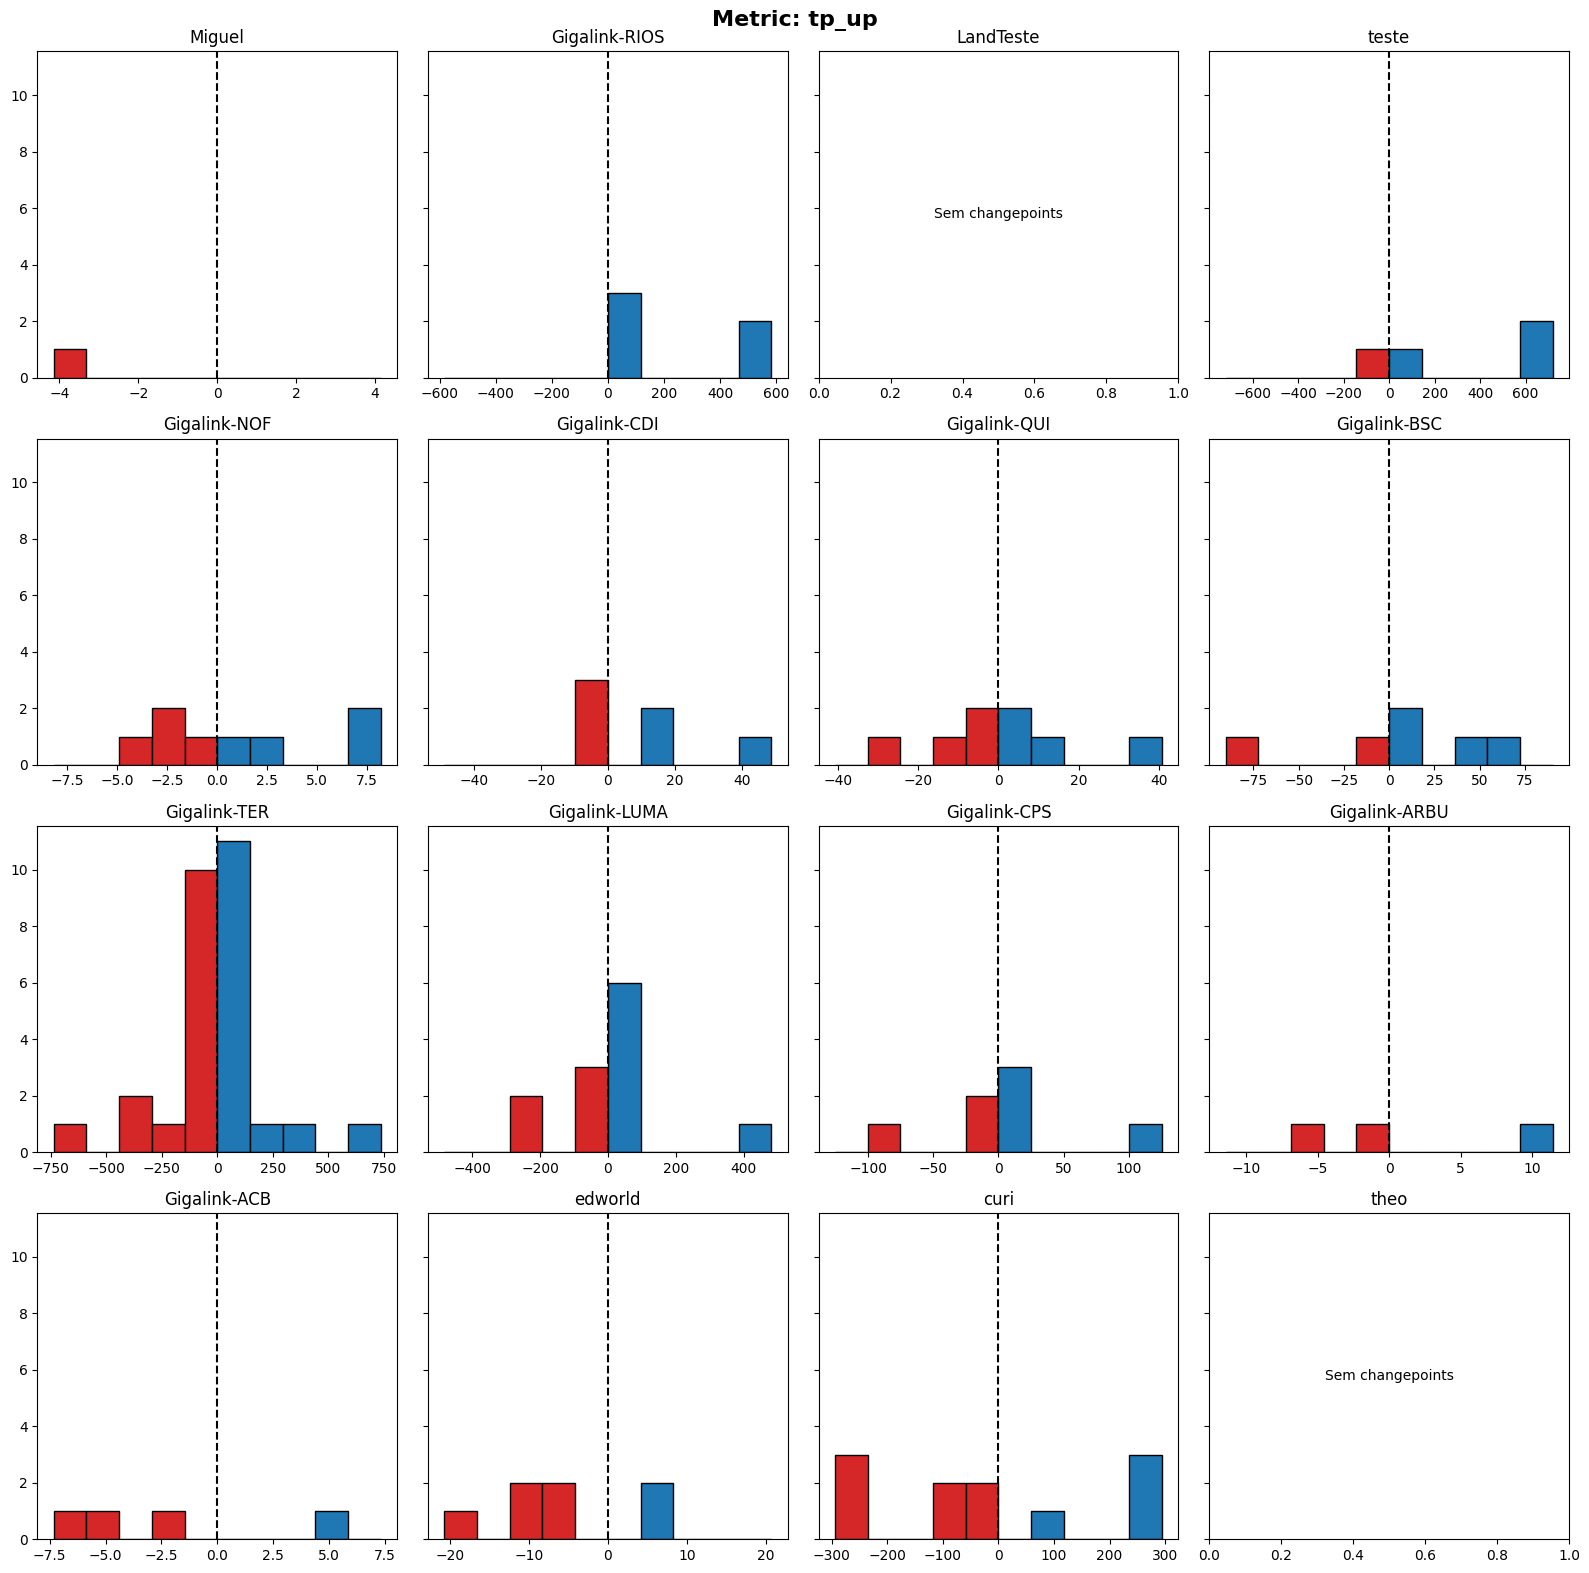

Plotting histogram for rtt_down...


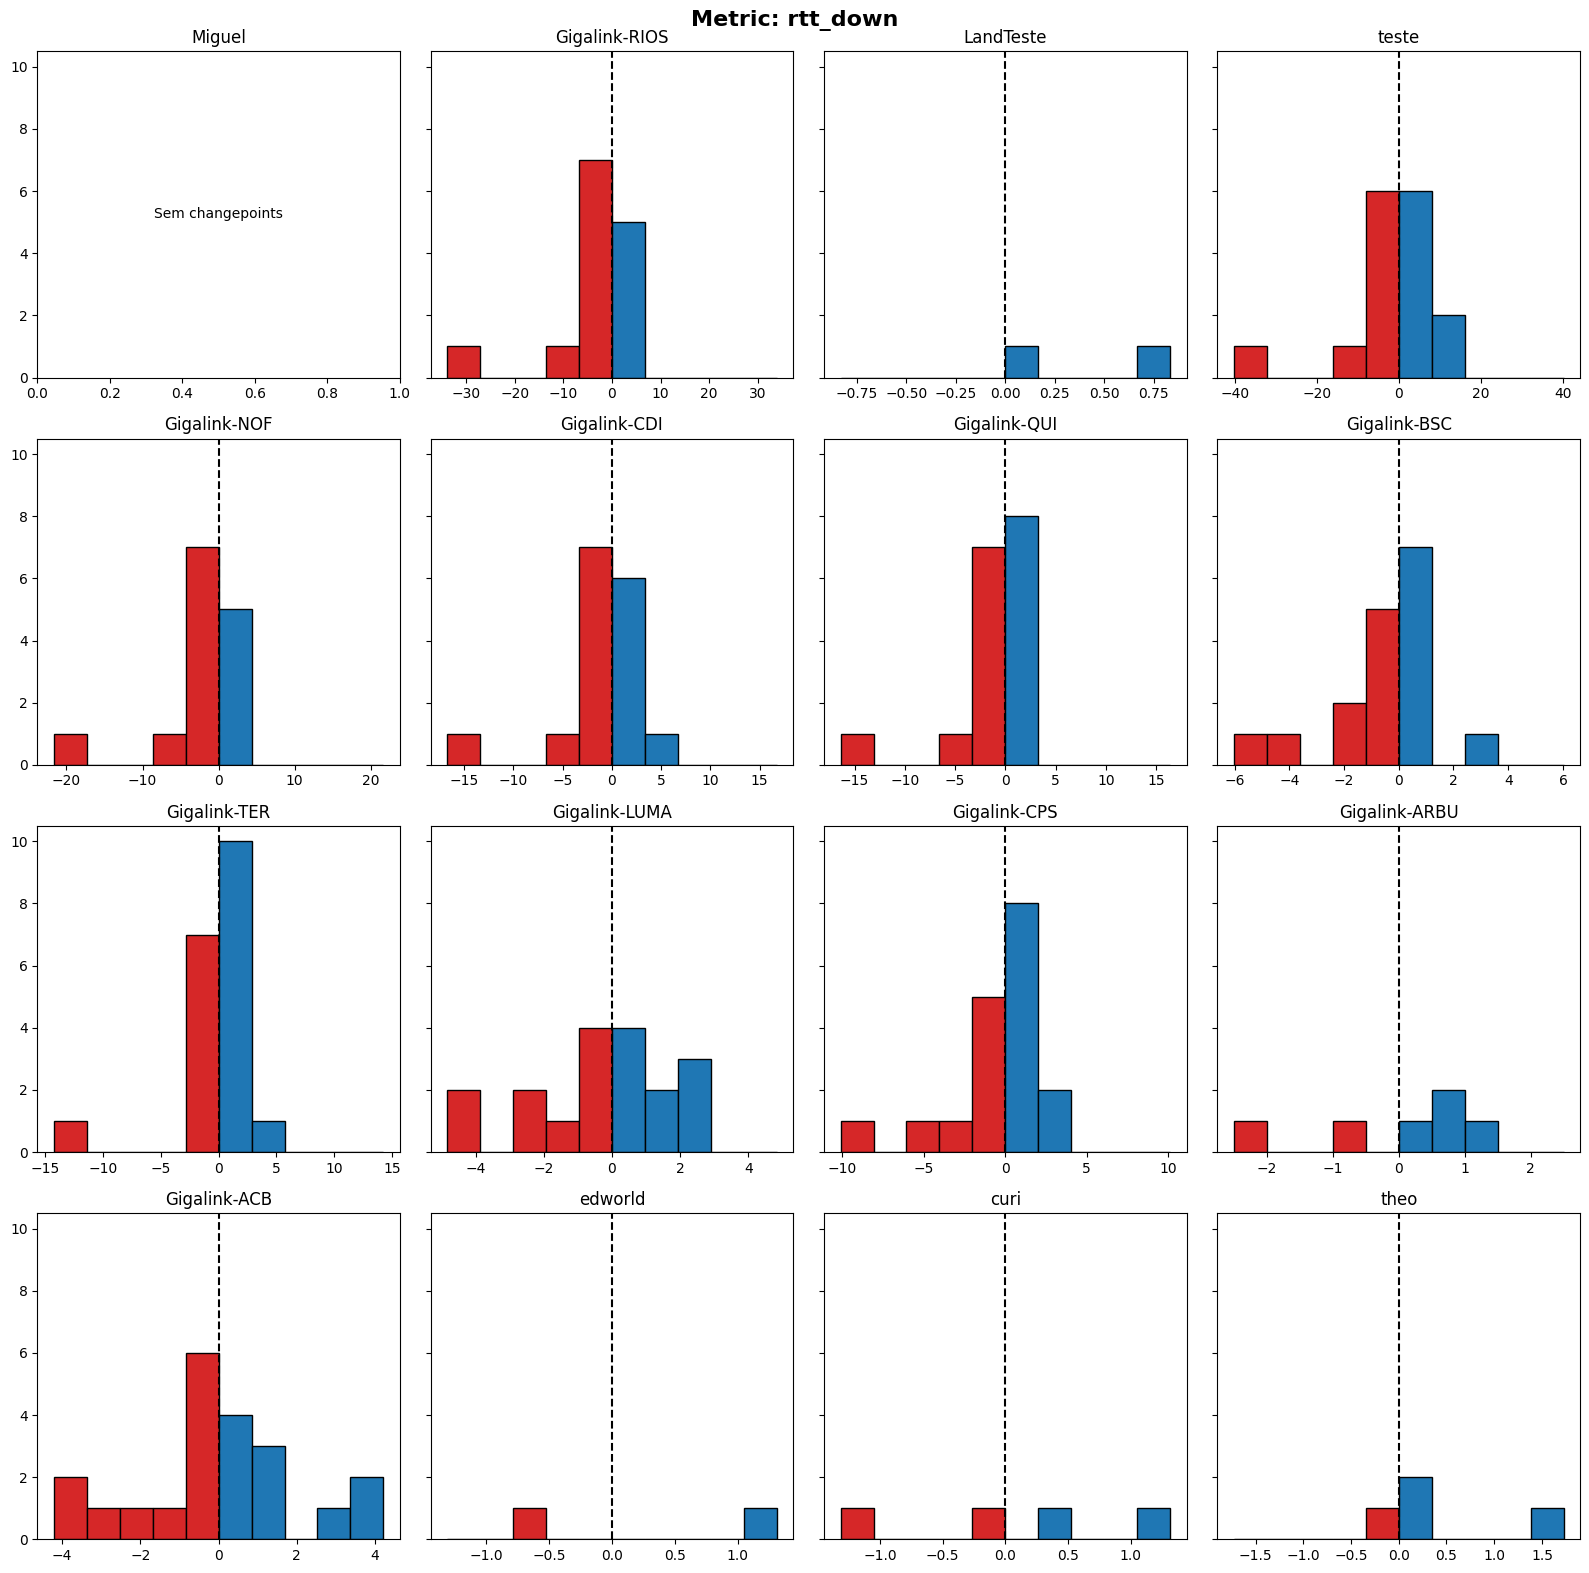

Plotting histogram for rtt_up...


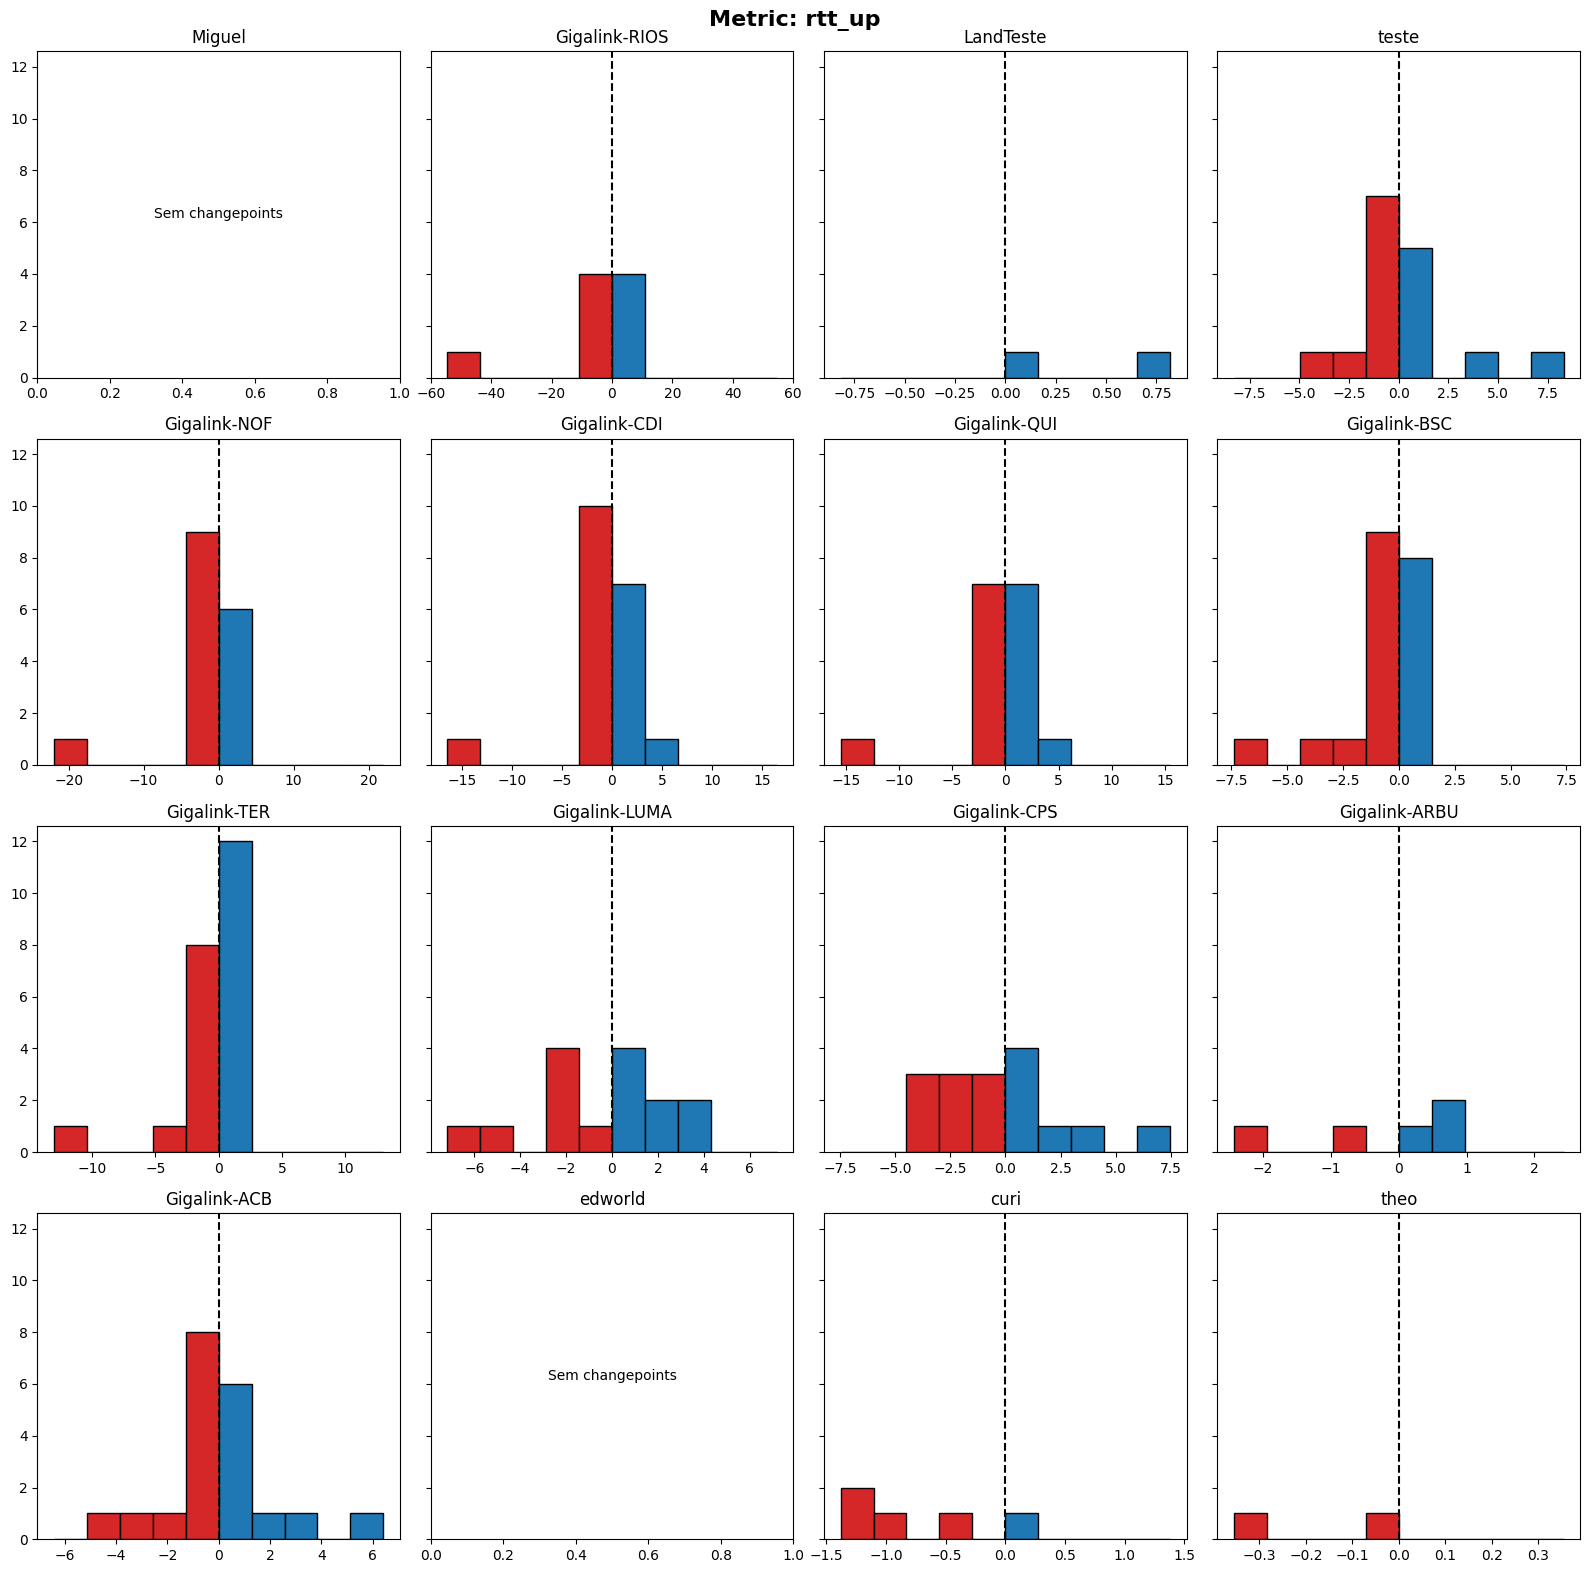

Plotting histogram for pl...


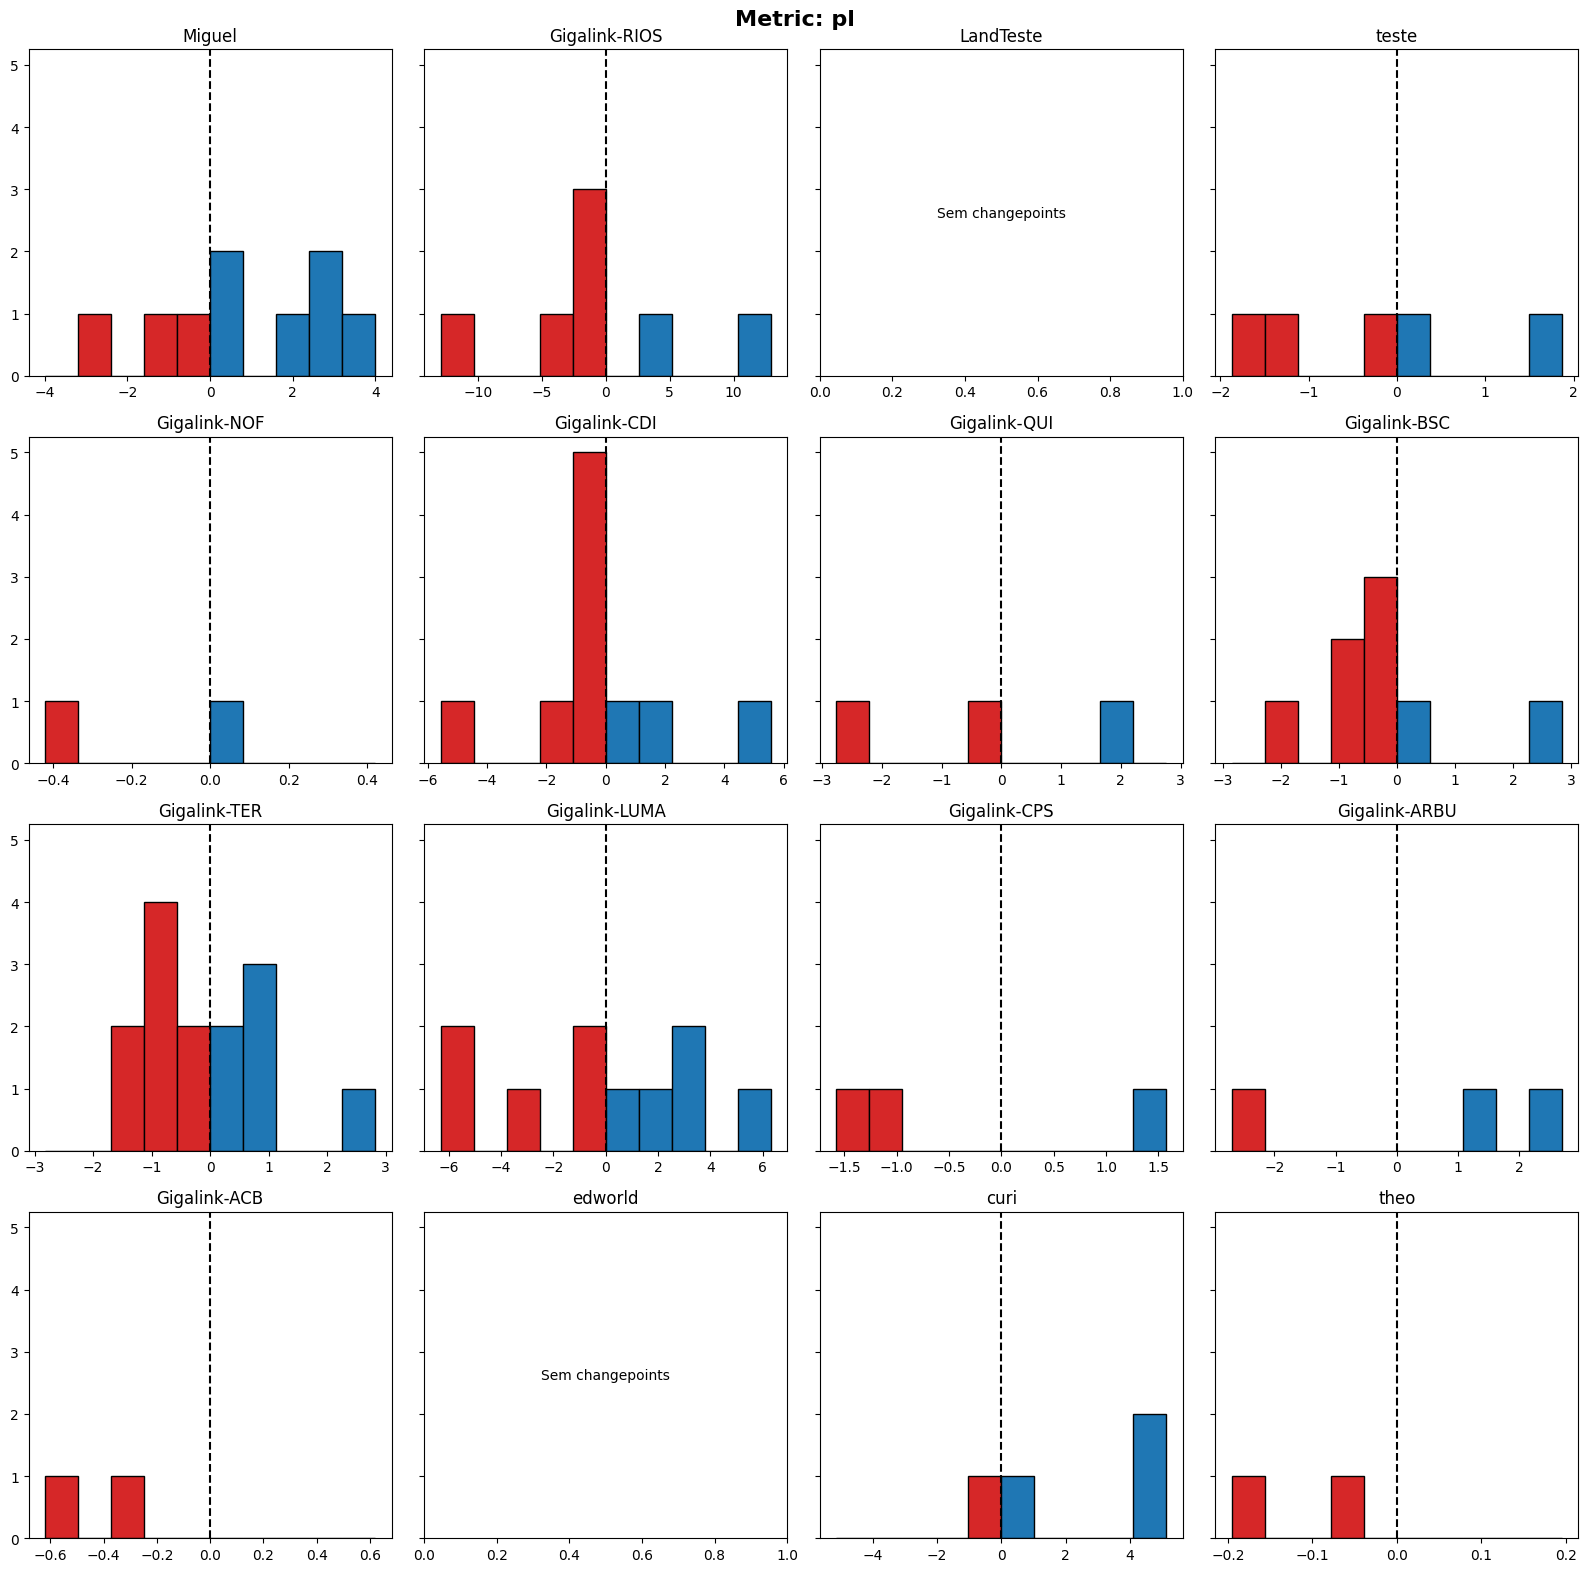

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_changepoint_histogram(scenario, metric, method):
    df = pd.read_csv(f"segments/{scenario}/{metric}/{method}.csv")
    clients = df['client'].unique()
    df = df.sort_values(by=['client', 'server', 'segment_order'])
    df['change'] = df.groupby(['client', 'server'])['mean'].diff()
    df = df.dropna(subset=['change'])
    cols = 4
    rows = math.ceil(len(clients) / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), squeeze=False, sharex=False, sharey=True)
    fig.suptitle(f'Metric: {metric}', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    for i, client in enumerate(clients):
        client_data = df[df['client'] == client]['change']
        if not client_data.empty:
            max_val = max(abs(client_data.min()), abs(client_data.max()))
            if max_val == 0:
                max_val = 1
                
            bins_edges = np.linspace(-max_val, max_val, 11)
            
            _, _, patches = axes[i].hist(client_data, bins=bins_edges, edgecolor='black')
            for patch in patches:
                color = '#d62728' if patch.get_x() + patch.get_width() / 2 < 0 else '#1f77b4'
                patch.set_facecolor(color)
            axes[i].axvline(0, color='black', linestyle='--', linewidth=1.5)
        else:
            axes[i].text(0.5, 0.5, 'Sem changepoints', ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(client)
    for j in range(len(clients), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

scenario = "NDT_AGO_OUT"
metrics = ["tp_down", "tp_up", "rtt_down", "rtt_up", "pl"]
method = "vwcd_0.95"
for metric in metrics:
    print(f"Plotting histogram for {metric}...")
    plot_changepoint_histogram(scenario, metric, method)